In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Load the dataset
df = pd.read_csv("IMDB Dataset.csv")

# Display first 5 rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# Check dataset shape
print("Dataset Shape:")
print(df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(50000, 2)

Column Names:
Index(['review', 'sentiment'], dtype='object')

Missing Values:
review       0
sentiment    0
dtype: int64


In [ ]:
# Count positive and negative reviews
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
from nltk.corpus import stopwords

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Function to clean text
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
df["clean_review"] = df["review"].apply(clean_text)

# Display first 5 cleaned reviews
df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one reviewers mentioned watching oz episode yo...
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically theres family little boy jake thinks...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [ ]:
# Convert text into numerical features
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

# Target variable
y = df["sentiment"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (50000, 5000)


In [ ]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (40000, 5000)
Testing Data Shape: (10000, 5000)


In [ ]:
# Create and train the model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed Successfully!")

Model Training Completed Successfully!


In [ ]:
# Predict on test data
y_pred = model.predict(X_test)

# Print accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 88.74 %

Classification Report:

              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4961
    positive       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [ ]:
# Function to predict sentiment
def predict_sentiment(review):
    # Clean the review
    review = clean_text(review)

    # Convert to TF-IDF
    review_vector = tfidf.transform([review])

    # Predict
    prediction = model.predict(review_vector)[0]

    return prediction

# Test reviews
review1 = "This movie was absolutely amazing. I loved every minute of it."
review2 = "This was the worst movie I have ever watched."

print("Review 1:", predict_sentiment(review1))
print("Review 2:", predict_sentiment(review2))

Review 1: positive
Review 2: negative


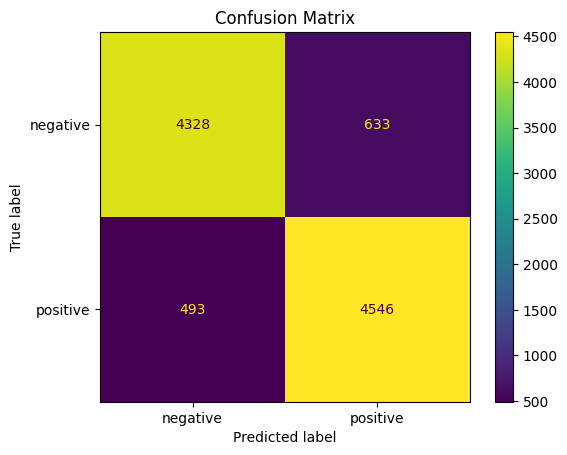

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.show()

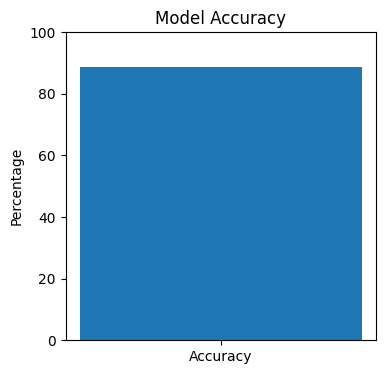

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.bar(["Accuracy"], [accuracy*100])
plt.ylim(0,100)
plt.ylabel("Percentage")
plt.title("Model Accuracy")
plt.show()

# Insights

- The dataset contains 50,000 movie reviews.
- Text preprocessing removed HTML tags, punctuation, and stopwords.
- TF-IDF was used to convert text into numerical features.
- Logistic Regression was used for sentiment classification.
- The model achieved high accuracy on the test dataset.
- Positive and negative reviews were classified successfully.